$$
\textbf{Nome: Gabriel Souza Almeida. } \\
\textbf{Matrícula: 2026010096}
$$

$$
\textbf{Nome: Valderi Alves de Souza Neto. } \\
\textbf{Matrícula: 2026010167}
$$

In [26]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [27]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
ionosphere = fetch_ucirepo(id=52) 
  
# data (as pandas dataframes) 
X = ionosphere.data.features 
y = ionosphere.data.targets 
  
# metadata 
# print(ionosphere.metadata) 
  
# variable information 
# print(ionosphere.variables) 

# Deixando tudo em um pandas
df = pd.concat([X, y], axis=1)

df

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34,Class
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,1,0,0.83508,0.08298,0.73739,-0.14706,0.84349,-0.05567,0.90441,-0.04622,...,-0.04202,0.83479,0.00123,1.00000,0.12815,0.86660,-0.10714,0.90546,-0.04307,g
347,1,0,0.95113,0.00419,0.95183,-0.02723,0.93438,-0.01920,0.94590,0.01606,...,0.01361,0.93522,0.04925,0.93159,0.08168,0.94066,-0.00035,0.91483,0.04712,g
348,1,0,0.94701,-0.00034,0.93207,-0.03227,0.95177,-0.03431,0.95584,0.02446,...,0.03193,0.92489,0.02542,0.92120,0.02242,0.92459,0.00442,0.92697,-0.00577,g
349,1,0,0.90608,-0.01657,0.98122,-0.01989,0.95691,-0.03646,0.85746,0.00110,...,-0.02099,0.89147,-0.07760,0.82983,-0.17238,0.96022,-0.03757,0.87403,-0.16243,g


# 1. Justificando algebricamente a necessidade da normalização para que o processo da regra Delta seja estavel. 
A necessidade de normalizar os atributos (**Z-score**) para estabilizar a Regra Delta do Adaline pode ser explicada analisando a equação de atualização dos pesos:
$$
w_{novo} = w_{atual} + \eta \cdot (erro) \cdot x_i
$$

Onde:
- $\eta$: é a taxa de aprendizagem.
- $x_i$: é o valor da entrada (atributo) naquele momento.

## O Problema (Sem Normalização)
Algebricamente, o tamanho do "salto" que o peso dá $(w_{novo} - w_{atual})$ é diretamente proporcional ao valor da entrada $x_i$.
Se tivermos um atributo na escala de `0.01` e outro na escala de `1000`, o atributo de maior valor vai gerar atualizações de peso gigantescas, enquanto o menor quase não alterará seu peso.
Para evitar que a atualização do peso do atributo de valor `1000` "exploda" (divirja), seríamos forçados a escolher um $\eta$ minúsculo, tornando o aprendizado inviavelmente lento.

## A Solução (Com Z-Score)
Ao aplicar a padronização **Z-score**, garantimos que todos os atributos $x_i$ tenham média `0` e variância `1` (ficando concentrados aproximadamente entre `-3` e `+3`).
Dessa forma, o fator $x_i$ na equação tem a mesma magnitude para todos os atributos. Isso equilibra a atualização dos pesos, permitindo que a rede convirja de forma estável e suave, e possibilita o uso de um $\eta$ razoável para toda a rede, sem o risco de saltos divergentes.

In [28]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# RECODIFICANDO CLASS
def classificar(q):
    if q == 'g':
        return 1
    elif q == 'b':
        return -1
    else:
        return 0

df['Class'] = df['Class'].apply(classificar)

# VERIFICANDO VALORES NULOS
print(df.info())

# VERIFICANDO ATRIBUTOS CONSTANTES E REMOVENDO
colunas_constantes = [col for col in X.columns if X[col].nunique() <= 1]
print(f"Campos nulos: {colunas_constantes}")
df = df.drop(columns=colunas_constantes)

# NORMALIZANDO COM Z-SCORE
X = df.drop(columns=["Class"])
y = df["Class"]
# Divisao treino / teste (É IMPORTANTE DIVIDIR ANTES DE NORMALIZAR)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizacao
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Pós normalização")
print(f"Amostras de treino : {X_train.shape[0]}")
print(f"Amostras de teste  : {X_test.shape[0]}")
print(f"Features           : {X_train.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 35 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Attribute1   351 non-null    int64  
 1   Attribute2   351 non-null    int64  
 2   Attribute3   351 non-null    float64
 3   Attribute4   351 non-null    float64
 4   Attribute5   351 non-null    float64
 5   Attribute6   351 non-null    float64
 6   Attribute7   351 non-null    float64
 7   Attribute8   351 non-null    float64
 8   Attribute9   351 non-null    float64
 9   Attribute10  351 non-null    float64
 10  Attribute11  351 non-null    float64
 11  Attribute12  351 non-null    float64
 12  Attribute13  351 non-null    float64
 13  Attribute14  351 non-null    float64
 14  Attribute15  351 non-null    float64
 15  Attribute16  351 non-null    float64
 16  Attribute17  351 non-null    float64
 17  Attribute18  351 non-null    float64
 18  Attribute19  351 non-null    float64
 19  Attribut

# 2. Valor de 𝜂 escolhido:

Com base nos gráficos, selecionamos **$\eta = 10^{-3}$** como a melhor taxa de aprendizagem. Pois ela proporciona:

- **Convergência suave**: a curva decresce sem oscilações;
- **Menor valor de MSE final**: entre as taxas estáveis é a menor, com 0.3704;
- **Estabilidade**: ao contrário de $\eta = 5 \times 10^{-2}$ e $\eta = 10^{-1}$, não apresenta divergência ou instabilidade numérica.

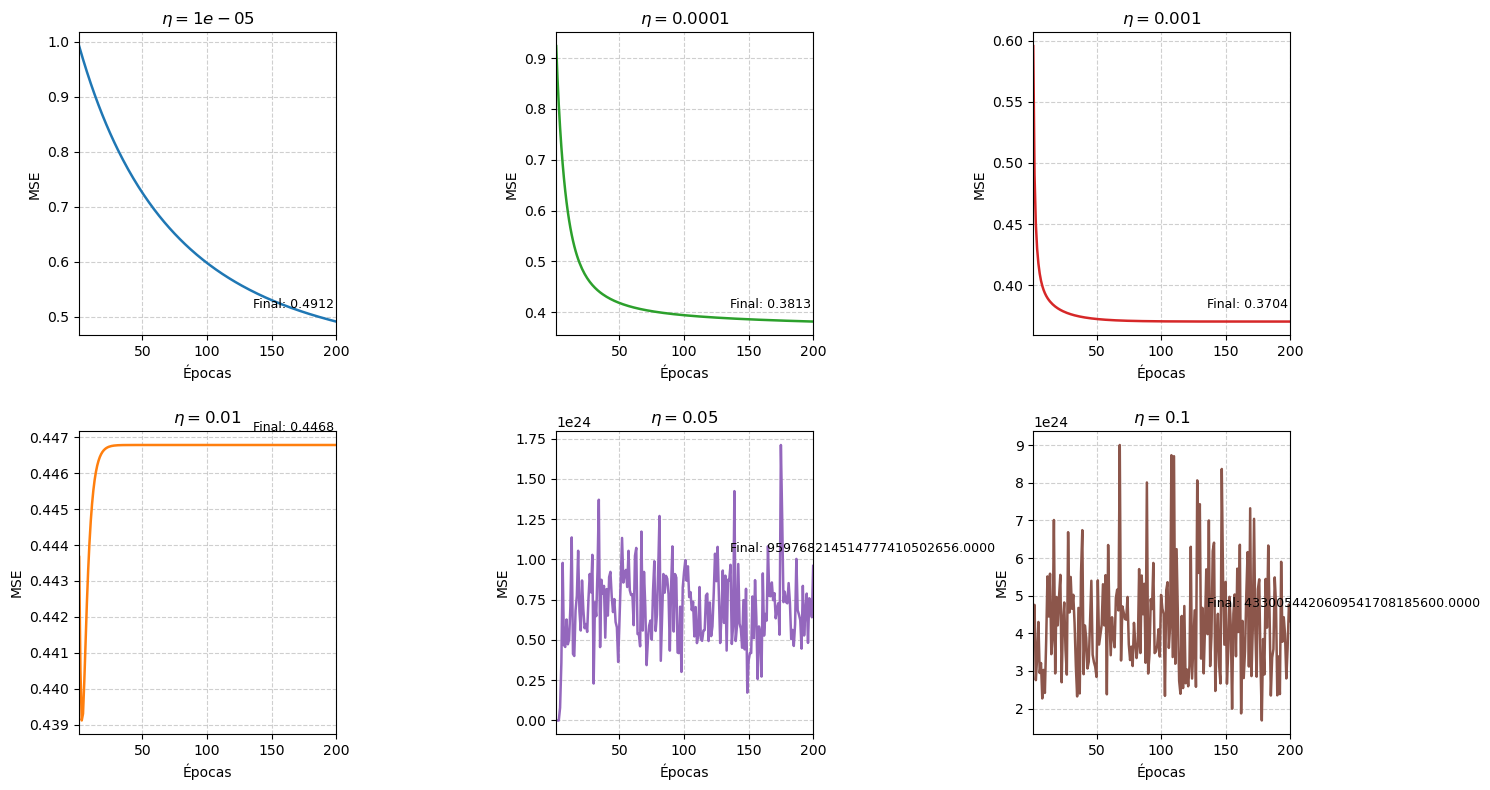

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

# SEPARAÇÃO DOS DADOS
# Os dados já foram separados na questão anterior.

# ESTUDO COM DIFERENTES VALORES DE TAXA DE APRENDIZAGEM
from sklearn.metrics import mean_squared_error

# Taxas de aprendizagem a serem avaliadas
taxas_aprendizagem = [1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
epocas = 200

historico = {} 

for eta in taxas_aprendizagem:
    clf = SGDClassifier(
        loss='squared_error',
        eta0=eta,
        learning_rate='constant',
        max_iter=1,
        shuffle=True,
        random_state=42,
        warm_start=True
    )
    curva = []
    for _ in range(epocas):
        clf.partial_fit(X_train, y_train, classes=[-1, 1])
        mse = mean_squared_error(y_train, clf.decision_function(X_train))
        curva.append(mse)
    historico[eta] = curva

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
epocas_array = np.arange(1, epocas + 1)
cores  = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#8c564b']

for ax, (eta, curva), cor in zip(axes, historico.items(), cores):
    curva_valida   = [c for c in curva if np.isfinite(c)]
    epocas_validas = epocas_array[:len(curva_valida)]
    ax.plot(epocas_validas, curva_valida, color=cor, linewidth=1.8)
    ax.set_xlabel('Épocas')
    ax.set_ylabel('MSE')
    ax.set_title(rf'$\eta = {eta}$')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim([1, epocas_array[-1]])
    if curva_valida:
        ax.annotate(f'Final: {curva_valida[-1]:.4f}',
                    xy=(epocas_validas[-1], curva_valida[-1]),
                    xytext=(-60, 10), textcoords='offset points', fontsize=9)

plt.tight_layout(h_pad=2.0, w_pad=0.01)
plt.show()

# 3. Treino e Indicadores

In [40]:
adaline_sklearn = SGDClassifier(
    loss='squared_error',
    eta0=0.001, # DEFINIDO PELA ANA
    learning_rate='constant',
    max_iter=200,
    shuffle=True,
    random_state=42
)
adaline_sklearn.fit(X_train, y_train)
y_pred_sklearn = adaline_sklearn.predict(X_test)

confusionMatriz = confusion_matrix(y_test, y_pred_sklearn)
print("Matriz de Confusão (Com sklearn):")
print(confusionMatriz)

print('Acurácia :', accuracy_score(y_test, y_pred_sklearn))
print('Precisão  :', precision_score(y_test, y_pred_sklearn))
print('Recall    :', recall_score(y_test, y_pred_sklearn))
print('F1-Score  :', f1_score(y_test, y_pred_sklearn))

Matriz de Confusão (Com sklearn):
[[22  3]
 [ 0 46]]
Acurácia : 0.9577464788732394
Precisão  : 0.9387755102040817
Recall    : 1.0
F1-Score  : 0.968421052631579


# 4. Análise do Erro Mais Crítico

A classe *bad* representa a **ausência de estrutura ionosférica coerente**, ou seja, os raios de rádio atravessaram a ionosfera sem reflexão útil. Em sistemas operacionais de radar e GPS, isso indica falha de transmissão, interferência severa ou perturbações geomagnéticas.

Por conta disso, o erro mais crítico é o **Falso Positivo**, pois nele o classificador acredita que a estrutura ionosférica está íntegra (*good*) quando, na verdade, o canal está degradado (*bad*). O sistema continuaria transmitindo dados cruciais por um canal falho, **sem alertar o operador**. Isso pode resultar em:

1. Transmissões corrompidas e não detectadas;
2. Falhas silenciosas em sistemas de navegação;
3. Ausência de alertas preventivos cruciais sobre tempestades geomagnéticas.

Um **Falso Negativo**, por outro lado, descarta um sinal que era válido por pura precaução. O sistema perde uma janela de comunicação ou refaz uma leitura, o que representa apenas um custo operacional menor e recuperável.

Portanto, em aplicações reais de monitoramento, **minimizar os Falsos Positivos** (maximizando a Precisão da classe *good*) é a prioridade absoluta. O custo de uma falsa garantia de segurança é catastroficamente maior do que o de uma oportunidade de transmissão perdida.

## Nosso modelo
Avaliando a matriz de confusão gerada pelo nosso modelo, observamos um cenário interessante:
* O modelo obteve **0 Falsos Negativos** (Recall perfeito de 100%), ou seja, ele jamais descartou erroneamente um sinal bom.
* Contudo, ele cometeu **3 Falsos Positivos**, que é exatamente o tipo de erro mais crítico discutido acima.

Isso conclui que, embora o modelo Adaline tenha apresentado uma alta capacidade geral de generalização (Acurácia de ~95.7%), em um cenário de aplicação crítica do mundo real, ele precisaria de ajustes para se tornar mais conservador e penalizar fortemente a ocorrência desses falsos positivos, visando a segurança do sistema.